In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip -q install wfdb scipy numpy pandas matplotlib

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import wfdb
from scipy.signal import stft, butter, filtfilt


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 8.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 18.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 151.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.1 which is incompatible.
db-dtypes 1.5.0 requires pandas<3.0.0,>=1.5.3, but you have pandas 3.0.1 which is incompatible.
dask-cudf-cu12 25.10.0 requires pandas<2.4.0dev0,>=2.0, but you have pandas 3.0.1 which is incompatible.
bqplot 0.12.45 requires pandas<3.0.0,>=1.0.0, but you have pandas 3.0.1 which is incompatible.
gradio 5.50.0 requires pandas<3.0,>=1.0, but you have pandas 3.0.1 which is incompatible.
cudf-cu12 25.10.0 requires pandas<2.4.0dev0,>=2.0, but you have pandas 3.0.1 which is incompatible.


In [ ]:
import os, numpy as np, pandas as pd, ast, torch

BASE = "/content/drive/MyDrive/Colab Notebooks"
X_NPY = os.path.join(BASE, "X_ptbxl_500hz.npy")
META  = os.path.join(BASE, "ptbxl_database.csv")
SCP   = os.path.join(BASE, "scp_statements.csv")

print("X:", os.path.exists(X_NPY))
print("META:", os.path.exists(META))
print("SCP:", os.path.exists(SCP))

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

X: True
META: True
SCP: True
Device: cuda


In [ ]:
!cp "{X_NPY}" /content/X_ptbxl_500hz.npy

X = np.load("/content/X_ptbxl_500hz.npy", mmap_mode="r")
print("X shape:", X.shape)  # expect (21799, 12, 5000) or (21799, 5000, 12)

X shape: (21799, 12, 5000)


In [ ]:
print("X shape:", X.shape)
print("One sample shape:", X[0].shape)



X shape: (21799, 12, 5000)
One sample shape: (12, 5000)


In [ ]:
i = 0  # try any index 0..21798
ecg = X[i].T   # (5000, 12)

print("ecg shape:", ecg.shape)  # must be (5000, 12)


ecg shape: (5000, 12)


In [ ]:
import numpy as np
from scipy.signal import butter, filtfilt

def bandpass_filter(x, fs=500, low=0.5, high=40.0, order=4):
    nyq = 0.5 * fs
    b, a = butter(order, [low/nyq, high/nyq], btype="band")
    return filtfilt(b, a, x, axis=0)

fs = 500
ecg_filt = bandpass_filter(ecg, fs=fs, low=0.5, high=40.0)

# z-score per lead
ecg_filt = (ecg_filt - ecg_filt.mean(axis=0)) / (ecg_filt.std(axis=0) + 1e-8)

print("ecg_filt shape:", ecg_filt.shape)


ecg_filt shape: (5000, 12)


In [ ]:
import numpy as np
from scipy.signal import butter, filtfilt

def bandpass_filter(x, fs=500, low=0.5, high=40.0, order=4):
    nyq = 0.5 * fs
    b, a = butter(order, [low/nyq, high/nyq], btype="band")
    return filtfilt(b, a, x, axis=0)

fs = 500
ecg_filt = bandpass_filter(ecg, fs=fs, low=0.5, high=40.0)

# z-score per lead
ecg_filt = (ecg_filt - ecg_filt.mean(axis=0)) / (ecg_filt.std(axis=0) + 1e-8)

print("ecg_filt shape:", ecg_filt.shape)


ecg_filt shape: (5000, 12)


In [ ]:
from scipy.signal import stft

def ecg_to_spectrogram_tensor(ecg_time_leads, fs=500, win_len=256, hop=128, nfft=512, fmax=40.0):
    specs = []
    for lead in range(ecg_time_leads.shape[1]):
        f, tt, Z = stft(
            ecg_time_leads[:, lead],
            fs=fs,
            nperseg=win_len,
            noverlap=win_len-hop,
            nfft=nfft,
            boundary=None,
            padded=False
        )
        mag = np.abs(Z)

        keep = f <= fmax
        mag = mag[keep, :]

        # log scaling
        mag = np.log1p(mag)

        # normalize spectrogram per lead (helps CNN)
        mag = (mag - mag.mean()) / (mag.std() + 1e-8)

        specs.append(mag.astype(np.float32))

    return np.stack(specs, axis=0), f[keep], tt

spec, f_keep, t_keep = ecg_to_spectrogram_tensor(ecg_filt, fs=fs)

print("Spectrogram shape (leads, freq, time):", spec.shape)


Spectrogram shape (leads, freq, time): (12, 41, 38)


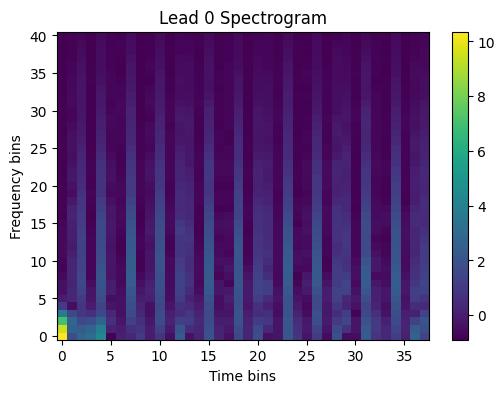

In [ ]:
import matplotlib.pyplot as plt

lead_idx = 0
plt.figure(figsize=(6,4))
plt.imshow(spec[lead_idx], aspect="auto", origin="lower")
plt.title(f"Lead {lead_idx} Spectrogram")
plt.xlabel("Time bins")
plt.ylabel("Frequency bins")
plt.colorbar()
plt.show()


In [ ]:
# ecg is (5000, 12) after transpose, ecg_filt is filtered

spec, f_keep, t_keep = ecg_to_spectrogram_tensor(ecg_filt, fs=500)
print(spec.shape)   # should be (12, freq_bins, time_bins)


(12, 41, 38)


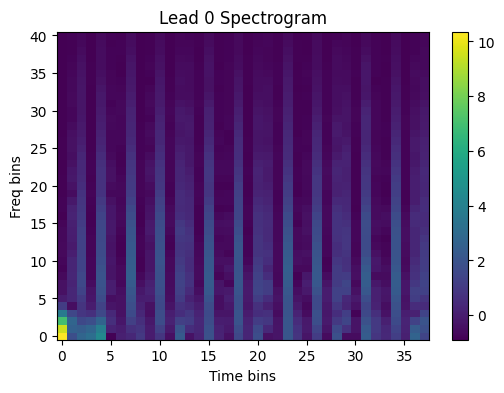

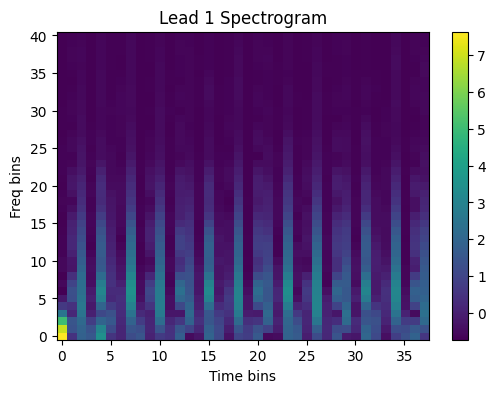

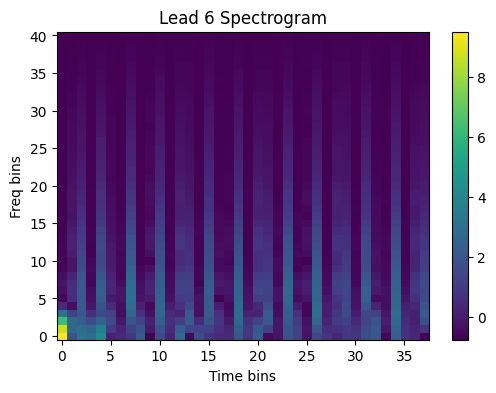

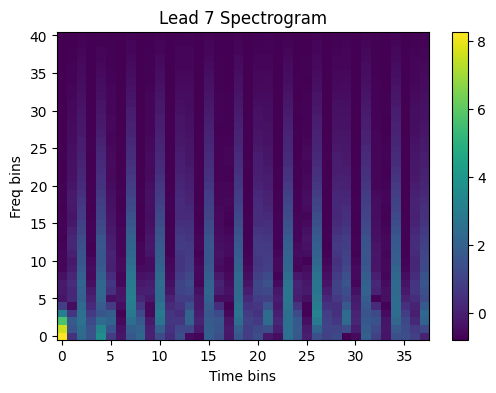

In [ ]:
import matplotlib.pyplot as plt

for lead_idx in [0, 1, 6, 7]:  # pick a few
    plt.figure(figsize=(6,4))
    plt.imshow(spec[lead_idx], aspect="auto", origin="lower")
    plt.title(f"Lead {lead_idx} Spectrogram")
    plt.xlabel("Time bins")
    plt.ylabel("Freq bins")
    plt.colorbar()
    plt.show()


In [ ]:
import glob
BASE = "/content/drive/MyDrive/Colab Notebooks"
print("NPY files:", glob.glob(BASE + "/*.npy"))
print("CSV files:", glob.glob(BASE + "/*.csv"))


NPY files: ['/content/drive/MyDrive/Colab Notebooks/X_ptbxl_500hz.npy']
CSV files: ['/content/drive/MyDrive/Colab Notebooks/scp_statements.csv', '/content/drive/MyDrive/Colab Notebooks/ptbxl_database.csv']
